In [1]:
from VSP_Auxiliary import *
from astropy.coordinates import match_coordinates_sky
from astropy.table import Table
from astropy.coordinates import EarthLocation
from astropy.time import Time
from astropy.timeseries import TimeSeries
from matplotlib import pyplot as plt
from scipy import optimize

In [12]:
def download_lamost_DR10(obsid, path):
    # 输入：obsid和保存路径(仅路径)
    # 函数下载lamost光谱到指定路径，格式为.fits.gz
    # 返回下载的url和下载的fits文件
    token = 'F4c25be9054' # My token
    url = r'http://www.lamost.org:80/dr10/v1.0/spectrum/fits/'+str(obsid)+r'?token='+token
    save_name = path + 'DR10LRS_' + str(obsid) + '.fits.gz'
    # 若之前存在文件，则不动
    if not os.path.exists(save_name):
        fitsfile = download_url(url, save_name)
    else:
        print(save_name,'already exists.')
        fitsfile = save_name
    return (url, fitsfile)

# 测试
#download_lamost_DR10(167804116, './Temp/')

In [13]:
def download_lamost_DR11(obsid, path):
    # 输入：obsid和保存路径(仅路径)
    # 函数下载lamost光谱到指定路径，格式为.fits.gz
    # 返回下载的url和下载的fits文件
    token = 'F4c25be9054' # My token
    url = r'http://www.lamost.org:80/dr11/v1.0/spectrum/fits/'+str(obsid)+r'?token='+token
    save_name = path + 'DR11LRS_' + str(obsid) + '.fits.gz'
    # 若之前存在文件，则不动
    if not os.path.exists(save_name):
        fitsfile = download_url(url, save_name)
    else:
        print(save_name,'already exists.')
        fitsfile = save_name
    return (url, fitsfile)

# 测试
#download_lamost_DR11(167804116, './Temp/')

In [4]:
def query_LM_DR10LRS_idx(coord, radius=2):
    # 输入坐标对象和搜索距离(单位为角秒)
    # 函数从LIB文件夹下保存DR10LRS所有坐标的星表文件中遍历查找是否存在一个小于搜索范围
    # 若查找到，返回列表的前五项为查找到的ra,dec,uid,original_DR10_order(在原始LRS总表中的序号),distance_as
    # 若没有查找到，返回False
    print('search radius:',radius,'arcsec')
    qra, qdec = coord.ra.to(u.deg).value, coord.dec.to(u.deg).value
    if qra>0 and qra<75:
        file = '/data1/sunyk_work_folder/VSP_v202406/LIB/LAMOST_DR10_LRS_radec_find_RAJ0004.fits'
    elif qra>75 and qra<150:
        file = '/data1/sunyk_work_folder/VSP_v202406/LIB/LAMOST_DR10_LRS_radec_find_RAJ0509.fits'
    elif qra>150 and qra<360:
        file = '/data1/sunyk_work_folder/VSP_v202406/LIB/LAMOST_DR10_LRS_radec_find_RAJ1023.fits'
    else:
        raise ValueError('Query ra invalid.')
        file = False
        
    if file:
        col_list = ['ra','dec','uid','original_DR10_order']
        data = read_fits_cols(file, col_list)
        coords_catalog = SkyCoord(ra=data[0], dec=data[1], unit=(u.degree, u.degree))
        index, sep, sep3d = match_coordinates_sky(matchcoord=coord, catalogcoord=coords_catalog)
        dist = sep.to(u.arcsec).value[0]
        if dist<radius:
            print('Found in LAMOST DR10LRS:\ndist("):',
                  dist, '   uid:',data[2][index], '   DR10LRS index:',data[3][index])
            return [data[0][index],data[1][index],data[2][index],data[3][index],dist,
                   ['ra','dec','uid','original_DR10_order','distance_as']]
        else:
            print(f'Not found in LAMOST DR10LRS within radius = {radius} arcsec.')
            return False
    else:
        return False
    
def read_LM_DR10LRS_CMD_fromIdx(idx):
    # 程序根据LAMOST DR10LRS星表的索引值，返回对应行的数据
    # 返回['obsid','uid','designation','class','subclass','z','z_err','ra','dec',
    #        'guo21_rgeo','green19_rgeo',
    #        'BPRP0_green19','MG_rgeo_green19','MG_rgeolo_green19','MG_rgeohi_green19',
    #        'rgeo','b_rgeo','B_rgeo','Gmag_DR3','pmRA_DR3','pmDE_DR3']
    if not (idx>=0 and idx<11817430):
        print('Index not valid for LAMOST DR10LRS catalog!')
        raise ValueError('Input index invalid.')
    else:
        select = '%02d'%(idx//1000000 + 1)
        file = f'/data1/sunyk_work_folder/VSP_v202406/LIB/LAMOST_DR10_LRS_CMD_Galactic_part{select}-12.fits'
        col_list = ['obsid','uid','designation','class','subclass','z','z_err','ra','dec',
                    'guo21_rgeo','green19_rgeo','Gmag','e_Gmag',
                    'BPRP0_green19','MG_rgeo_green19','MG_rgeolo_green19','MG_rgeohi_green19',
                    'rgeo','b_rgeo_x','B_rgeo_xa','RUWE','RPlx','pmRA','pmDE']
        data = read_fits_cols(file, col_list)
        row = []
        for col in data:
            row.append(col[idx%1000000])
        row.append(['obsid','uid','designation','class','subclass','z','z_err','ra','dec',
                    'guo21_rgeo','green19_rgeo','Gmag','e_Gmag',
                    'BPRP0_green19','MG_rgeo_green19','MG_rgeolo_green19','MG_rgeohi_green19',
                    'rgeo','b_rgeo','B_rgeo','RUWE','RPlx','pmRA','pmDE'])
        return row

def find_DR10LRS_multiephoch_fromuid(uid):
    # 输入uid(字符串或整型)
    # 通过uid寻找是否有多次观测，返回包含所有obsid的列表
    # 分别读入LIB文件夹下multiepoch星表每一部分，遍历查找obsid，查找后输出星表内保存的obsid_list
    # 若有重复观测则返回obsid_list, 无重复观测则返回只包含自身的列表

    col_list = ['uid','obsid_list']
    found = False
    if uid[0] == 'G':
        if uid[1:3] == '10' or uid[1:3] == '11' or uid[1:3] == '12' or uid[1:3] == '13' or uid[1:3] == '14':
            mec_fits_file = '/data1/sunyk_work_folder/VSP_v202406/LIB/dr10_v1.0_LRS_mec_G10-14.fits'
            print('read DR10 mec-file:', mec_fits_file)
            data = read_fits_cols(mec_fits_file, col_list) # 读入当前部分星表
            for k in range(len(data[0])):
                if uid == data[0][k]:
                    obsidlist = data[1][k]
                    found = obsidlist.split(';')
        elif uid[1:3] == '15':
            mec_fits_file = '/data1/sunyk_work_folder/VSP_v202406/LIB/dr10_v1.0_LRS_mec_G15.fits'
            print('read DR10 mec-file:', mec_fits_file)
            data = read_fits_cols(mec_fits_file, col_list) # 读入当前部分星表
            for k in range(len(data[0])):
                if uid == data[0][k]:
                    obsidlist = data[1][k]
                    found = obsidlist.split(';')
        elif uid[1:3] == '16':
            mec_fits_file = '/data1/sunyk_work_folder/VSP_v202406/LIB/dr10_v1.0_LRS_mec_G16.fits'
            print('read DR10 mec-file:', mec_fits_file)
            data = read_fits_cols(mec_fits_file, col_list) # 读入当前部分星表
            for k in range(len(data[0])):
                if uid == data[0][k]:
                    obsidlist = data[1][k]
                    found = obsidlist.split(';')
        elif uid[1:3] == '17':
            mec_fits_file = '/data1/sunyk_work_folder/VSP_v202406/LIB/dr10_v1.0_LRS_mec_G17.fits'
            print('read DR10 mec-file:', mec_fits_file)
            data = read_fits_cols(mec_fits_file, col_list) # 读入当前部分星表
            for k in range(len(data[0])):
                if uid == data[0][k]:
                    obsidlist = data[1][k]
                    found = obsidlist.split(';')
        else:
            mec_fits_file = '/data1/sunyk_work_folder/VSP_v202406/LIB/dr10_v1.0_LRS_mec_G87-99.fits'
            print('read DR10 mec-file:', mec_fits_file)
            data = read_fits_cols(mec_fits_file, col_list) # 读入当前部分星表
            for k in range(len(data[0])):
                if uid == data[0][k]:
                    obsidlist = data[1][k]
                    found = obsidlist.split(';')
    elif uid[0] == 'L' or uid[0] == 'P':
        mec_fits_file = '/data1/sunyk_work_folder/VSP_v202406/LIB/dr10_v1.0_LRS_mec_LP.fits'
        print('read DR10 mec-file:', mec_fits_file)
        data = read_fits_cols(mec_fits_file, col_list) # 读入当前部分星表
        for k in range(len(data[0])):
            if uid == data[0][k]:
                obsidlist = data[1][k]
                found = obsidlist.split(';')
    else:
        print('UID not found in LAMOST DR10 mec catalog.')
    return found

def find_LM_DR10LRS(coord, radius=2):
    # 输入坐标对象
    # 函数先搜索是否存在一个obsid，然后根据找到的obsid搜索所有观测
    # 若DR10LRS中不存在，则返回False；若存在，则返回第一个obsid的搜索结果、第一个obsid的数据、以及包含所有obsid的列表
    
    print('>>> Step 1: find index for LAMOST DR10LRS catalog...')
    try:
        r = query_LM_DR10LRS_idx(coord, radius=radius) # 查找最近的一个，获取整个星表里的索引
    except:
        r = False
    if r:
        #print()
        print('>>> Step 2: get archived data from LAMOST DR10LRS catalog...')
        dr10idx = r[3]
        d = read_LM_DR10LRS_CMD_fromIdx(dr10idx) # 获取完整数据
        # print()
        print('>>> Step 3: find multiple observations in LAMOST DR10LRS...')
        obsid = d[0]
        uid = d[1]
        obsidlist = find_DR10LRS_multiephoch_fromuid(uid) # 查找多次观测
        if obsidlist:
            print('--> DR10 observation times:',len(obsidlist))
            print('    DR10 obsid list:',obsidlist)
        else:
            print(f'--> No multiple observations for obsid: {obsid}.')
            obsidlist = [obsid]

        tbl1 = Table(names=r[-1], dtype=('f4', 'f4', 'S18', 'i4', 'f4'))
        tbl1.add_row([r[0],r[1],r[2],r[3],r[4]])
        tbl2 = Table(names=d[-1], dtype=(
            'i4', 'S18', 'S20', 'S10', 'S10','f4', 'f4', 'f4', 'f4', 'f4', 'f4',\
            'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4', 'f4'))
        tbl2.add_row([d[ii] for ii in range(len(d[-1]))])
        return (tbl1,tbl2,obsidlist)
    else:
        print(f'Data not found in LAMOST DR10LRS for ra,dec: {coord.ra.value} {coord.dec.value}.')
        return False

# 测试
#coord = SkyCoord(ra=103.1549367983, dec=+24.60618197635, unit=(u.deg,u.deg), frame='icrs')
#r = find_LM_DR10LRS(coord, radius=2.0)
#if r:
#    tb1,tb2,obslist = r
#    print(tb1)
#    print(tb2)
#    print(obslist)

In [5]:
def read_sp(sp_file):
    with fits.open(sp_file) as fitsfile:# 读入fits
        data=fitsfile[1].data[0]
        wave=data[2]
        flux=data[0]
        obsid=fitsfile[0].header['obsid']
        designation=fitsfile[0].header['desig']
        mjd=fitsfile[0].header['mjd']
        medianutc=fitsfile[0].header['DATE-OBS']
        z=fitsfile[0].header['z']
        zerr=fitsfile[0].header['z_err']
        spclass=fitsfile[0].header['class']
        subclass=fitsfile[0].header['subclass']
        snru,snrg,snrr=fitsfile[0].header['snru'],fitsfile[0].header['snrg'],fitsfile[0].header['snrr']
    return wave,flux,fitsfile[0].header

In [6]:
def draw_spectrum(sp_file, rest=False, save_file=None, ifplot=False, lines=['H','HeI','HeII','CaII','CIII/NIII','CII','OIII','NaI'], dpi=600):
    # 输入：sp_file光谱文件名，rest=True固定谱线为静止波长否则按红移移动，save_file保存文件位置，lines选择要绘制的谱线，dpi绘制的分辨率
    # 绘制的光谱是lamost原始的，绘制的谱线通过乘以(1+z)改正到观测波长
    # 读取光谱文件sp_file，绘制光谱并保存至指定文件
    
    XLIM=(3700,9000) # 设置绘制光谱波长范围
    colorlist=['red','dodgerblue','blue','gold','plum','orange','#62eeb7'] # 谱线颜色表
    linewidth = 0.8 # 谱线标注宽度
    fsize = 9 # 谱线字体大小
    legendfontsize = 7 # 图例大小
    
    # 谱线列表 v20231103 LAMOST=1.00026512*NIST+0.070275226
    # ----------------------------------------------------
    # Balmer lines
    ha = 6564.6127 # LAMOST
    hb = 4862.6778 # LAMOST
    hg = 4341.6803 # LAMOST / NIST-AIR 4340.472    
    hd = 4102.89 # LAMOST
    he = 3970.075*1.0002754 # NIST-AIR
    h8=3890.1653
    h9=3836.484116
    h10=3798.986177
    # CaII lines
    cak=3934.77
    cah=3969.59
    caii31=8500.35
    caii32=8544.44
    caii33=8664.52
    # HeI lines
    hei = [3889.749, 4025.110, 4389.163, 4472.736, 4714.466,
           4923.306, 5017.078, 5877.249, 6679.992, 7067.14, 7283.36] # 3937.026, 3820.690, 3832.641, 3706.058, 5049.147,
    # HeII lines
    heii4686 = 4687.0
    heii5411 = 5411    
    # CIII/NIII lines
    c3=4650
    # CII
    cii7234 = 7233.31
    # ----------------------------------------------------
    wave,flux,header = read_sp(sp_file)
    obsid=header['obsid']
    designation=header['desig']
    mjd=header['mjd']
    medianutc=header['DATE-OBS']
    z=header['z']
    zerr=header['z_err']
    spclass=header['class']
    subclass=header['subclass']
    snru,snrg,snrr=header['snru'],header['snrg'],header['snrr']
    if z > -9999:
        redshift = z
        z1 = z
    else:
        redshift = 0
        zerr = 0
        z1 = np.nan
    if rest:
        redshift = 0
        print('Lines are plotted in rest frame.')
        moretxt = '  (rest line wavelenth)'
    else:
        moretxt = '  (redshifted line wavelenth)'
    obs_location = [117.57722 * u.deg, 40.395833 * u.deg, 900 * u.m]
    obs_site = EarthLocation(lon=obs_location[0], lat=obs_location[1], height = obs_location[2])
    obs_jd = Time(medianutc, format='isot', scale='utc', location=obs_site)
    try:
        titletext0 = f'obsid: {obsid}   {designation}    MJD{mjd}  mid_MJD{round(obs_jd.jd-2400000.5,6)}    '+\
                    f'snru/g/r: {round(snru,1)}/{round(snrg,1)}/{round(snrr,1)}    '+\
                    f'z: {round(z,6)}  zerr: {round(np.abs(zerr/z*100),2)}%  RV = {round(z1*299792.458,1)} km/s'+\
                    f'    CLASS: {spclass}-{subclass}' + moretxt
        titletext = f'obsid: {obsid}   {designation}    MJD{mjd}  mid_MJD{round(obs_jd.jd-2400000.5,6)}    '+\
                    f'snru/g/r: {round(snru,1)}/{round(snrg,1)}/{round(snrr,1)}    '+\
                    f'z: {round(z,6)}  RV = {round(z1*299792.458,1)}±{round(zerr*299792.458,1)} km/s'+\
                    f'    CLASS: {spclass}-{subclass}' + moretxt
    except:
        z = np.nan
        titletext0 = f'obsid: {obsid}   {designation}    MJD{mjd}  mid_MJD{round(obs_jd.jd-2400000.5,6)}    '+\
                    f'snru/g/r: {round(snru,1)}/{round(snrg,1)}/{round(snrr,1)}    '+\
                    f'z: {round(z,6)}  zerr: {np.round(np.abs(zerr/z*100),2)}%  RV = {round(z1*299792.458,1)} km/s'+\
                    f'    CLASS: {spclass}-{subclass}' + moretxt
        titletext = f'obsid: {obsid}   {designation}    MJD{mjd}  mid_MJD{round(obs_jd.jd-2400000.5,6)}    '+\
                    f'snru/g/r: {round(snru,1)}/{round(snrg,1)}/{round(snrr,1)}    '+\
                    f'z: {round(z,6)}  RV = {round(z1*299792.458,1)}±{round(zerr*299792.458,1)} km/s'+\
                    f'    CLASS: {spclass}-{subclass}' + moretxt

    f = plt.figure(figsize=(16.5,3.8),dpi=dpi)
    plt.xlim(XLIM)

    if 'H' in lines:
        HI=plt.axvline(x=ha*(1+redshift),color=colorlist[0],linestyle='dotted',linewidth=linewidth)
        plt.axvline(x=hb*(1+redshift),color=colorlist[0],linestyle='dotted',linewidth=linewidth)
        plt.axvline(x=hg*(1+redshift),color=colorlist[0],linestyle='dotted',linewidth=linewidth)
        plt.axvline(x=hd*(1+redshift),color=colorlist[0],linestyle='dotted',linewidth=linewidth)
        plt.axvline(x=he*(1+redshift),color=colorlist[0],linestyle='dotted',linewidth=linewidth)
        plt.axvline(x=h8*(1+redshift),color=colorlist[0],linestyle='dotted',linewidth=linewidth)
        plt.axvline(x=h9*(1+redshift),color=colorlist[0],linestyle='dotted',linewidth=linewidth)
        plt.axvline(x=h10*(1+redshift),color=colorlist[0],linestyle='dotted',linewidth=linewidth)
    if 'CaII' in lines:
        Ca=plt.axvline(x=cak*(1+redshift),color=colorlist[5],linestyle='dotted',linewidth=linewidth)
        plt.axvline(x=cah*(1+redshift),color=colorlist[5],linestyle='dotted',linewidth=linewidth)
        plt.axvline(x=caii31*(1+redshift),color=colorlist[5],linestyle='dotted',linewidth=linewidth)
        plt.axvline(x=caii32*(1+redshift),color=colorlist[5],linestyle='dotted',linewidth=linewidth)
        plt.axvline(x=caii33*(1+redshift),color=colorlist[5],linestyle='dotted',linewidth=linewidth)    
    if 'CII' in lines:
        CII=plt.axvline(x=cii7234*(1+redshift),color=colorlist[3],linestyle='dotted',linewidth=linewidth)    
    if "HeI" in lines:
        for hew in hei:
            if hew == hei[0]:
                HeI=plt.axvline(x=hew*(1+redshift),color=colorlist[1],linestyle='dotted',linewidth=linewidth)
            else:
                plt.axvline(x=hew*(1+redshift),color=colorlist[1],linestyle='dotted',linewidth=linewidth)                
    if "HeII" in lines:    
        HeII=plt.axvline(x=heii4686*(1+redshift),color=colorlist[2],linestyle='dotted',linewidth=linewidth)            
        plt.axvline(x=heii5411*(1+redshift),color=colorlist[2],linestyle='dotted',linewidth=linewidth)           
    if 'CIII/NIII' in lines:
        C3=plt.axvline(x=c3*(1+redshift),color=colorlist[4],linestyle='dotted',linewidth=linewidth)
    plist = []
    labellist = []
    if 'H' in lines:
        plist.append(HI)
        labellist.append('HI')
    if 'HeI' in lines:
        plist.append(HeI)
        labellist.append('HeI')
    if 'HeII' in lines:
        plist.append(HeII)
        labellist.append('HeII')
    if 'CIII/NIII' in lines:
        plist.append(C3)
        labellist.append('CIII/NIII')
    if 'CaII' in lines:
        plist.append(Ca)
        labellist.append('CaII')
    if 'CII' in lines:
        plist.append(CII)
        labellist.append('CII')
    plt.legend(plist,labellist,loc='upper right',fontsize=legendfontsize)

    plt.plot(wave,flux,color='black',linewidth=0.33,linestyle='-')
    plt.xticks(np.arange(4000,9000,500), fontsize=11)
    plt.yticks(fontsize=11)
    plt.xlabel('Wavelength(Å)', fontsize=12)
    plt.ylabel('Relative Flux', fontsize=12)
    plt.title(titletext, fontsize=9.2)
    if save_file is not None:
        plt.savefig(save_file, bbox_inches='tight', dpi=dpi)
        print('Spectrum has been saved to '+save_file+'.')
    if ifplot:
        plt.show()
    plt.clf()
    plt.close()
    plt.close('all')
    return save_file

# 测试
#draw_spectrum('./Temp/DR10LRS_167804116.fits.gz', save_file='./Temp/DR10LRS_167804116.png')

In [22]:
def lamost_rvs(splist):
    # 输入光谱列表
    # 读入所有光谱，生成RV曲线，输出ts_hjd, ts_bjd
    obs_location = [117.57722 * u.deg, 40.395833 * u.deg, 960 * u.m] # 确认兴隆站LAMOST坐标是否正确
    obs_site = EarthLocation(lon=obs_location[0], lat=obs_location[1], height=obs_location[2])
 
    rvs = np.empty(len(splist))
    rverrs = np.empty(len(splist))
    hjds = np.empty(len(splist))
    bjds = np.empty(len(splist))
    # 读入所有lamost光谱
    for i in range(len(splist)):
        with fits.open(splist[i]) as fitsfile:
            exptime=fitsfile[0].header['EXPTIME']
            medianutc=fitsfile[0].header['DATE-OBS']
            z=fitsfile[0].header['z']
            zerr=fitsfile[0].header['z_err']
            obsid=fitsfile[0].header['obsid']
            ra=fitsfile[0].header['ra']
            dec=fitsfile[0].header['dec']
            if z == -9999:
                rv = np.nan
                rv_err = np.nan
            else:
                rv = z*299792.458
                rv_err = zerr*299792.458
            JD_time = Time(medianutc, format='isot', scale='utc', location=obs_site)
            obj_coord = SkyCoord(ra=ra,dec=dec,unit=(u.deg,u.deg),frame='fk5')
            # calculate HJD (UTC)
            ltt_helio = JD_time.light_travel_time(obj_coord, 'heliocentric')
            _HJD = (JD_time.utc + ltt_helio)
            hjd = _HJD.jd
            # calculate BJD (TDB)
            """
            NOTE: HJD (UTC) and BJD (TDB) can be up to +/- 4 mins different from
            each other, hence should not be ignored when studying short-period
            variability
            """
            ltt_bary = JD_time.light_travel_time(obj_coord, 'barycentric')
            _BJD = (JD_time.tdb + ltt_bary)
            bjd = _BJD.jd
            
            rvs[i] = rv
            rverrs[i] = rv_err
            hjds[i] = hjd
            bjds[i] = bjd
     # 建立RV时间序列
    time_hjd = Time(hjds, format='jd', scale='utc')
    time_bjd = Time(bjds, format='jd', scale='tdb')
    velocity = rvs.tolist()
    velocity_err = rverrs.tolist()
    ts_hjd = TimeSeries(time=time_hjd, data={"rv":velocity, "rv_err":velocity_err})
    ts_bjd = TimeSeries(time=time_bjd, data={"rv":velocity, "rv_err":velocity_err})
    return ts_hjd, ts_bjd
# 测试
# LAMOST LB-1
obslist = ['399904106', '483204134', '485104134', '486304134', '486804134',\
           '490504134', '497204134', '501104134', '506604134', '508804134',\
           '509804134', '510704134', '603204083', '606204083', '615304083',\
           '617804083', '620204083', '631104083', '644904083']
#create_dir('./Temp/LAMOST-LB1')
# spfiles = []
# for obs in obslist:
#     spfiles.append(download_lamost_DR10(obs, './Temp/LAMOST-LB1/')[1])
# print(spfiles)
# ts1,ts2 = lamost_rvs(spfiles)
# ts1.write('./Temp/LAMOST_LB1_lrs_rvs_hjd.csv',format='ascii.csv'),ts2.write('./Temp/LAMOST_LB1_lrs_rvs_bjd.csv',format='ascii.csv')

./Temp/LAMOST-LB1/DR10LRS_399904106.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_483204134.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_485104134.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_486304134.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_486804134.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_490504134.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_497204134.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_501104134.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_506604134.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_508804134.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_509804134.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_510704134.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_603204083.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_606204083.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_615304083.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_617804083.fits.gz already exists.
./Temp/LAMOST-LB1/DR10LRS_620204083.fits

(None, None)

In [8]:
def flux_clip(wave, flux, sigma_hi=3.9, sigma_lo=3.6):
    # 输入：波长和流量列表，裁切上下限(默认3.9，3.6)
    # 功能：裁切流量范围，超出范围的置为np.nan，返回修改后的波长和流量
    wave = np.array(wave)
    flux = np.array(flux)
    
    center = np.nanmedian(flux) # 获取中位流量
    std = np.nanstd(flux) # 获取流量标准差
    
    cut = (flux < center+sigma_hi*std) & (flux > center-sigma_lo*std) # 筛选
    wave[~cut] = np.nan 
    flux[~cut] = np.nan
    return wave, flux
    
from scipy.signal import medfilt

def median_filter(flux, n=3):
    return medfilt(flux, n)

# 测试
#wave = [300.,300.5,301.,301.5,302.,302.5,303,304,305,306]
#flux = [2.00,10.00,18.0,22.00,20.5,128.0,11.,12.,22.,26.]
#wave1, flux1 = flux_clip(wave,flux,sigma_hi=2., sigma_lo=2.)
#flux2 = median_filter(flux)
#plt.plot(wave, flux)
#plt.plot(wave1,flux1)
#plt.plot(wave, flux2)

In [9]:
from scipy.fftpack import fft,ifft

def fft_smooth(flux, threashold=900, ifplot=False):
    # 输入：光谱流量数组，裁切高频的阈值，是否绘制效果图片
    # fft平滑，裁切频率大于设置值的信号，返回平滑后的流量数组
    
    # FFT
    func_fft = fft(flux) # 快速傅里叶变换
    func_amp = np.abs(func_fft) # 取模
    frq = np.arange(len(flux))
    
    if ifplot:
        #绘制频域图像
        f = plt.figure(2, figsize=(5,3), dpi=100)
        func_amp = func_amp / max(func_amp) #振幅归一化
        plt.plot(frq, func_amp, linewidth=0.5)
        plt.xlabel("frequency")
        plt.ylim(-0.02,0.2)
        plt.title("FFT")
        plt.clf()
        plt.close(f)
        plt.close('all')
    # ---裁切高频---
    f_cut_threshold = threashold
    cut_center = len(flux) / 2
    f_cut_range = cut_center - f_cut_threshold
    cut_center_left = int(cut_center - f_cut_range)
    cut_center_right = int(cut_center + f_cut_range)
    func_fft[cut_center_left:cut_center_right] = 0

    if ifplot:        
        #绘制频域图像
        func_amp = np.abs(func_fft) #取模
        frq = np.arange(len(flux))
        f = plt.figure(2, figsize=(5,3), dpi=100)
        func_amp = func_amp/max(func_amp) #振幅归一化
        plt.plot(frq, func_amp, linewidth=0.5)
        plt.ylim(-0.02,0.2)
        plt.xlabel("frequency")
        plt.title(f"FFT_cut threashold={threashold}")
        plt.clf()
        plt.close(f)
        plt.close('all')
        
    #逆傅里叶变换
    func_ifft = ifft(func_fft)
    flux_ifft = func_ifft.real
    return flux_ifft

In [51]:
# 定义谱线波长列表
c = 299792.458
# # H I
# ha = 6564.6127 # LAMOST
# hb = 4862.6778 # LAMOST
# hg = 4341.6803 # LAMOST / NIST-AIR 4340.472    
# hd = 4102.89 # LAMOST
# he = 3970.075*1.0002754 # NIST-AIR
# # Ca II
# cak = 3934.78 # LAMOST
# cah = 3969.59 # LAMOST
# ca31 = 8500.35 # LAMOST
# ca32 = 8544.44 # LAMOST
# ca33 = 8664.52 # LAMOST
# # He I
# hei3819 = 3819.6074*1.0002754  # NIST-AIR  
# hei3705 = 3705.005*1.0002754  # NIST-AIR  
# hei3889 = 3888.648*1.0002754  # NIST-AIR  
# hei3965 = 3964.7291*1.0002754  # NIST-AIR
# hei4026 = 4026.1914*1.0002754  # NIST-AIR  
# hei4388 = 4387.9296*1.0002754  # NIST-AIR  
# hei4471 = 4471.4802*1.0002754  # NIST-AIR 
# hei4713 = 4713.1457*1.0002754  # NIST-AIR  
# hei4922 = 4921.9313*1.0002754  # NIST-AIR 
# hei5016 = 5015.6783*1.0002754  # NIST-AIR
# hei5876 = 5875.621*1.0002754  # NIST-AIR
# hei6678 = 6678.151*1.0002754  # NIST-AIR
# hei7065 = 7065.190*1.0002754  # NIST-AIR
# # He II
# heii4686 = 4685.8*1.0002754  # NIST-AIR
# heii4200 = 4200*1.0002754 # grey P70
# heii4541 = 4541*1.0002754 # grey P70
# heii5411 = 5411.52*1.0002754 # grey P74 5411.52

colorlist = ['orangered','dodgerblue','blue','gold','plum','#f6af60','#62eeb7']

def plot_ha(redshift, xshift, texty, yrange):
    h = 6564.6127 # LAMOST
    text = r'H$\alpha$ (rest)'
    y_range = yrange[1]-yrange[0]
    plt.axvline(x=h*(1+redshift), color='r', linestyle='solid', linewidth=1, alpha=0.8, zorder=2)
    #plt.axvline(x=h*(1+redshift), color='#DDDDDD', linestyle='solid', linewidth=800/c*h, alpha=0.72, zorder=1)
    #plt.axvline(x=h*(1+redshift), color='#CCCCCC', linestyle='solid', linewidth=400/c*h, alpha=0.8, zorder=1)
    plt.fill_between([h*(1-200/c),h*(1+200/c)],yrange[0]*0.6,yrange[1]*2, facecolor='#A9A9A9', alpha=0.85, zorder=1)
    plt.fill_between([h*(1-400/c),h*(1+400/c)],yrange[0]*0.6,yrange[1]*2, facecolor='#DDDDDD', alpha=0.72, zorder=1)
    #plt.axvline(x=h*(1+400/c), color='r', linestyle='solid', linewidth=.4, alpha=1, zorder=1) # 测试+400km/s
    #plt.axvline(x=h*(1-400/c), color='r', linestyle='solid', linewidth=.4, alpha=1, zorder=1)
    plt.text(h*(1+redshift)+xshift, texty+y_range/80, text, color='r', fontsize=7)
    plt.text(6527, texty+y_range*0.015, '±200km/s', color='#CACACA', fontsize=4.5)
    plt.text(6527, texty-y_range/30, '±400km/s', color='#DDDDDD', fontsize=4.5)
    
def plot_hb(redshift, xshift, texty, yrange):
    h = 4862.6778 # LAMOST
    text = r'H$\beta$ (rest)'
    y_range = yrange[1]-yrange[0]
    plt.axvline(x=h*(1+redshift), color='r', linestyle='solid', linewidth=1, alpha=0.8, zorder=2)
    plt.fill_between([h*(1-200/c),h*(1+200/c)],yrange[0]*0.6,yrange[1]*2, facecolor='#A9A9A9', alpha=0.85, zorder=1)
    plt.fill_between([h*(1-400/c),h*(1+400/c)],yrange[0]*0.6,yrange[1]*2, facecolor='#DDDDDD', alpha=0.72, zorder=1)
    #plt.axvline(x=h*(1+400/c), color='r', linestyle='solid', linewidth=.4, alpha=1, zorder=1) # 测试+400km/s
    #plt.axvline(x=h*(1-400/c), color='r', linestyle='solid', linewidth=.4, alpha=1, zorder=1)
    plt.text(h*(1+redshift)+xshift, texty+y_range/80, text, color='r', fontsize=7)
    plt.text(4839, texty+y_range*0.015, '±200km/s', color='#CACACA', fontsize=4.5)
    plt.text(4839, texty-y_range/30, '±400km/s', color='#DDDDDD', fontsize=4.5)

def plot_hg(redshift, xshift, texty, yrange):
    h = 4341.6803 # LAMOST
    text = r'H$\gamma$ (rest)'
    y_range = yrange[1]-yrange[0]
    plt.axvline(x=h*(1+redshift), color='r', linestyle='solid', linewidth=1, alpha=0.8, zorder=2)
    plt.fill_between([h*(1-200/c),h*(1+200/c)],yrange[0]*0.6,yrange[1]*2, facecolor='#A9A9A9', alpha=0.85, zorder=1)
    plt.fill_between([h*(1-400/c),h*(1+400/c)],yrange[0]*0.6,yrange[1]*2, facecolor='#DDDDDD', alpha=0.72, zorder=1)
    #plt.axvline(x=h*(1+400/c), color='r', linestyle='solid', linewidth=.4, alpha=1, zorder=1) # 测试+400km/s
    #plt.axvline(x=h*(1-400/c), color='r', linestyle='solid', linewidth=.4, alpha=1, zorder=1)
    plt.text(h*(1+redshift)+xshift, texty+y_range/80, text, color='r', fontsize=7)
    plt.text(4322, texty+y_range*0.015, '±200km/s', color='#CACACA', fontsize=4.5)
    plt.text(4322, texty-y_range/30, '±400km/s', color='#DDDDDD', fontsize=4.5)

def plot_hd(redshift, xshift, texty, yrange):
    h = 4102.89 # LAMOST
    text = r'H$\delta$ (rest)'
    y_range = yrange[1]-yrange[0]
    plt.axvline(x=h*(1+redshift), color='r', linestyle='solid', linewidth=1, alpha=0.8, zorder=2)
    plt.fill_between([h*(1-200/c),h*(1+200/c)],yrange[0]*0.6,yrange[1]*2, facecolor='#A9A9A9', alpha=0.85, zorder=1)
    plt.fill_between([h*(1-400/c),h*(1+400/c)],yrange[0]*0.6,yrange[1]*2, facecolor='#DDDDDD', alpha=0.72, zorder=1)
    #plt.axvline(x=h*(1+400/c), color='r', linestyle='solid', linewidth=.4, alpha=1, zorder=1) # 测试+400km/s
    #plt.axvline(x=h*(1-400/c), color='r', linestyle='solid', linewidth=.4, alpha=1, zorder=1)
    plt.text(h*(1+redshift)+xshift, texty+y_range/80, text, color='r', fontsize=7)
    plt.text(4084, texty+y_range*0.015, '±200km/s', color='#CACACA', fontsize=4.5)
    plt.text(4084, texty-y_range/30, '±400km/s', color='#DDDDDD', fontsize=4.5)

def plot_he(redshift, xshift, texty, yrange):
    h = 3970.075*1.0002754 # NIST-AIR
    text = r'H$\epsilon$ (rest)'
    y_range = yrange[1]-yrange[0]
    plt.axvline(x=h*(1+redshift), color='r', linestyle='solid', linewidth=1, alpha=0.8, zorder=2)
    plt.fill_between([h*(1-200/c),h*(1+200/c)],yrange[0]*0.6,yrange[1]*2, facecolor='#A9A9A9', alpha=0.85, zorder=1)
    plt.fill_between([h*(1-400/c),h*(1+400/c)],yrange[0]*0.6,yrange[1]*2, facecolor='#DDDDDD', alpha=0.72, zorder=1)
    #plt.axvline(x=h*(1+400/c), color='r', linestyle='solid', linewidth=.4, alpha=1, zorder=1) # 测试+400km/s
    #plt.axvline(x=h*(1-400/c), color='r', linestyle='solid', linewidth=.4, alpha=1, zorder=1)
    plt.text(h*(1+redshift)+xshift, texty+y_range/80, text, color='r', fontsize=7)
    plt.text(3953.5, texty+y_range*0.015, '±200km/s', color='#CACACA', fontsize=4.5)
    plt.text(3953.5, texty-y_range/30, '±400km/s', color='#DDDDDD', fontsize=4.5)

Hα line center: 6564.6127 Å
Gaussian fit parameters
miu fit:	6560.005 ± 0.311 Å
sigma fit:	6.22 ± 0.35 Å
FWHM fit:	14.64 ± 0.82 Å
RV fit:		-210.41 ± 14.21 km/s
line_name
---------
   Haplha

line_center(A)
--------------
     6564.6127

 fitted_center(A)
-----------------
6560.005320307699

fitted_center_err(A)
--------------------
  0.3111002104017639

radial_velocity(km/s)
---------------------
  -210.40962293087173

radial_velocity_err(km/s)
-------------------------
       14.207311386498393

 fitted_sigma(A) 
-----------------
6.218783674783584

fitted_sigma_err(A)
-------------------
0.34935055687593636

  fitted_fwhm(A) 
-----------------
14.64411645309161

fitted_fwhm_err(A)
------------------
0.8226576940741797

  sigma_v(km/s)  
-----------------
283.9991525522356

sigma_v_err(km/s) 
------------------
15.954126608186003

   fwhm_v(km/s)  
-----------------
668.7668972018068

 fwhm_v_err(km/s)
-----------------
37.56909713791803

Hε line center: 3971.1684 Å
Gaussian fit param

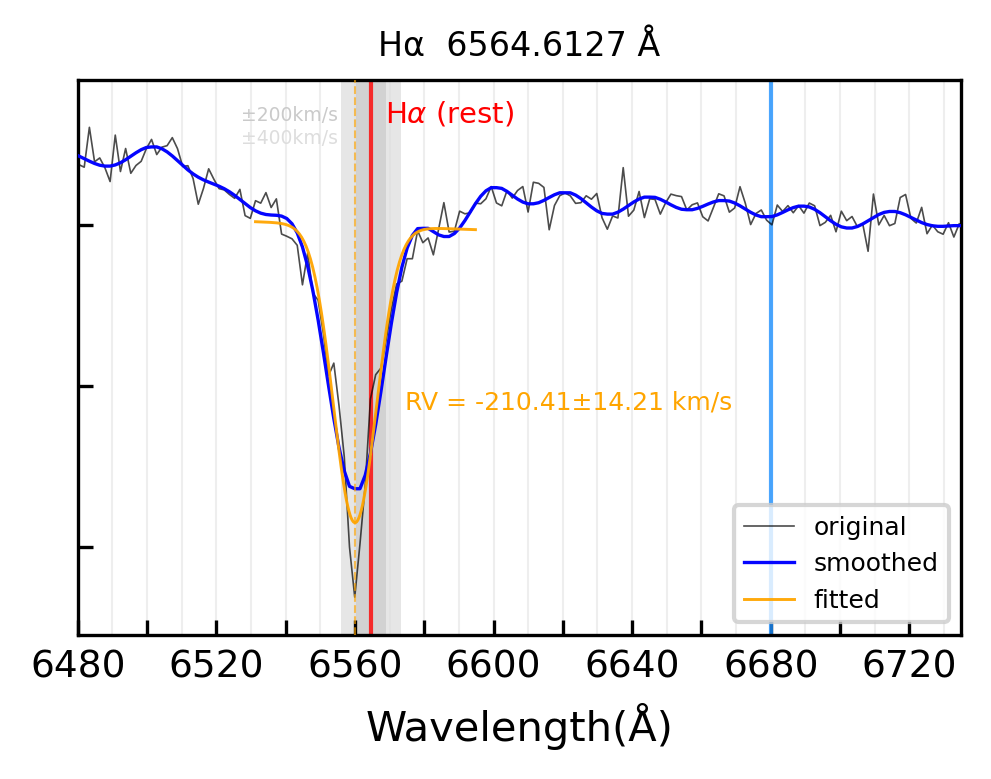

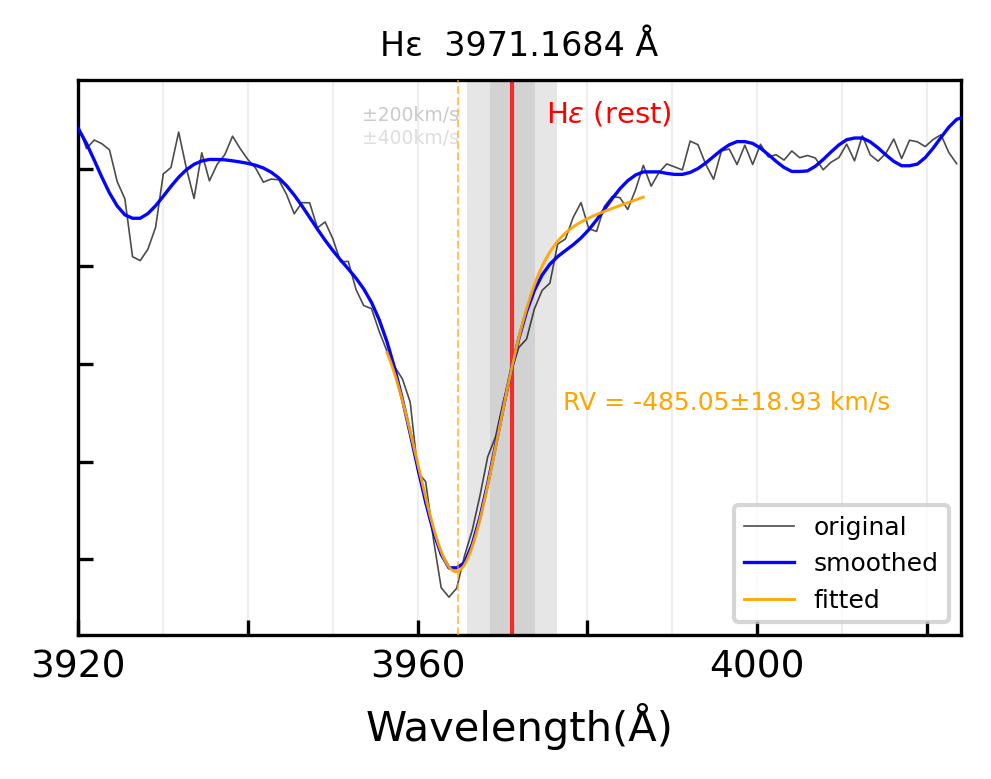

In [63]:
def f_gauss(x, amp, miu, slop, const, sigma):
    return amp*np.exp(-(x-miu)**2/(2*sigma**2)) + slop*x + const

def plot_balmer(wave,flux,line=3, ifshow=False, gaussian_fit=False, save_file=None):
    # 输入：波长，流量，绘制的谱线，是否进行高斯拟合，是否保存图片
    # line：3-Halpha,4-Hbeta,5-Hgamma,6-Hdelta,7-Hepsilon+CaH
    # 选择绘制Hαlpha到Hepsilon中的一个区域，同时可进行高斯拟合并输出高斯拟合参数
    if line not in [3,4,5,6,7]:
        raise ValueError('Invalid line selection! (line can be 3, 4, 5, 6, or 7)')
    fit_result = []
    
    c = 299792.458 # 真空光速km/s  
    # 谱线波长
    hei6678 = 6678.151*1.0002754  # NIST-AIR
    wavec = np.array([6564.6127, 4862.6778, 4341.6803, 4102.89, 3970.075*1.0002754],dtype=np.float64)    
    n = line-3 # Halpha + HeI, Hbeta, Hgamma, Hdelta, Hepsilon/CaH + CaK
    range_select = [
        (6480, 6735),
        (4790, 4940),
        (4280, 4400),
        (4050, 4160),
        (3920, 4024)
    ]
    xrange = range_select[n] # 设置绘图x范围
    cut = (wave > xrange[0]) & (wave < xrange[1])  
    wave1 = wave[cut]
    flux1 = flux[cut]
    upper_range = np.nanmax(flux1)
    lower_range = np.nanmin(flux1)
    yrange = (lower_range, upper_range) # 设置绘图y范围
    y_range = upper_range - lower_range    
    texty = (upper_range+lower_range)/2 + 9./9*y_range/2 # 文字高度   
    # 滤波平滑
    flux_fft = fft_smooth(flux, threashold=270) # 限制后的光谱做傅里叶变换降噪
    flux_sm  = median_filter(flux_fft)

    plt.figure(figsize=(3.8,2.4),dpi=300)
    wavegrid = np.arange(3800,6900,10)
    for i in wavegrid:
        plt.axvline(x=i, color='#EEEEEE', linestyle='solid', linewidth=0.5, alpha=1, zorder=0)
        
    line_names = ['Hα', 'Hβ', 'Hγ', 'Hδ', 'Hε']
    line_names2 = ['Haplha', 'Hbeta', 'Hgamma', 'Hdelta', 'Hepsilon']
    if line == 3:
        plot_ha(redshift=0, xshift=4, texty=texty, yrange=yrange)
        plt.axvline(x=hei6678, color=colorlist[1], linestyle='solid', linewidth=1., alpha=.8)
    elif line == 4:
        plot_hb(redshift=0, xshift=4, texty=texty, yrange=yrange)
    elif line == 5:
        plot_hg(redshift=0, xshift=4, texty=texty, yrange=yrange)
    elif line == 6:
        plot_hd(redshift=0, xshift=4, texty=texty, yrange=yrange)
    elif line == 7:
        plot_he(redshift=0, xshift=4, texty=texty, yrange=yrange)

    p1, = plt.plot(wave1, flux1,   color='k', linewidth=0.4, alpha=0.7, zorder=3)  # 绘制原始光谱
    p2, = plt.plot(wave,  flux_sm, color='b', linewidth=0.8, alpha=0.98, zorder=4) # 绘制降噪后的光谱
    plots = [p1,p2]
    
    if gaussian_fit:
        successed = True
        a = [6530,4830,4323,4080,3955]
        b = [6595,4896,4358,4119,3988]
        cutf = (wave>a[n]) & (wave<b[n])
        wavef,fluxf = wave[cutf], flux[cutf]
        try:
            popt, pcov = optimize.curve_fit(f_gauss, wavef, fluxf, 
                                            p0=[np.nanmax(fluxf)-np.nanmin(fluxf), wavec[n], 0,
                                            np.nanmedian(fluxf), 10])
        except:
            try:
                popt, pcov = optimize.curve_fit(f_gauss, wavef, fluxf, 
                                                p0=[np.nanmax(fluxf)-np.nanmin(fluxf), wavec[n]-5, 0,
                                                np.nanmedian(fluxf), 10])
            except:
                try:
                    popt, pcov = optimize.curve_fit(f_gauss, wavef, fluxf, 
                                                p0=[np.nanmax(fluxf)-np.nanmin(fluxf), wavec[n]+5, 0,
                                                np.nanmedian(fluxf), 10])
                except:
                    try:
                        popt, pcov = optimize.curve_fit(f_gauss, wavef, fluxf, 
                                                p0=[np.nanmax(fluxf)-np.nanmin(fluxf), wavec[n]-5, 0,
                                                np.nanmedian(fluxf), 18])
                    except:
                        try:
                            popt, pcov = optimize.curve_fit(f_gauss, wavef, fluxf, 
                                                p0=[np.nanmax(fluxf)-np.nanmin(fluxf), wavec[n]+5, 0,
                                                np.nanmedian(fluxf), 18])
                        except:
                            successed = False
        if successed:
            rv = (popt[1]-wavec[n])/wavec[n]*c
            rverr = np.sqrt(pcov[1][1])/wavec[n]*c
            print(f'* {line_names[n]} line center: {wavec[n]:.4f} Å')
            print('--- Gaussian fit parameters ---')
            print(f'miu fit:\t{popt[1]:.3f} ± {np.sqrt(pcov[1][1]):.3f} Å')
            print(f'sigma fit:\t{popt[-1]:.2f} ± {np.sqrt(pcov[-1][-1]):.2f} Å')
            fwhm = 2*np.sqrt(2*np.log(2))*popt[-1]
            fwhmerr = 2*np.sqrt(2*np.log(2))*np.sqrt(pcov[-1][-1])
            print(f'FWHM fit:\t{fwhm:.2f} ± {fwhmerr:.2f} Å')
            #print('covariances:\n', pcov)
            print(f'RV fit:\t\t{rv:.2f} ± {rverr:.2f} km/s')
            mdx = np.linspace(min(wavef),max(wavef),201)
            p3, = plt.plot(mdx, f_gauss(mdx,*popt),  color='orange', linewidth=0.7, alpha=0.95, zorder=5)
            plt.axvline(x=popt[1], color='orange', linestyle='dashed', linewidth=.5, alpha=0.64, zorder=5)
            plots.append(p3)
            texty2 = (upper_range+lower_range)/2 - 0.2*y_range/2
            plt.text(wavec[n]*1.0015,texty2,f'RV = {rv:.2f}±{rverr:.2f} km/s',color='orange',fontsize=6)
            names = ['line_name','line_center(A)',\
                     'fitted_center(A)','fitted_center_err(A)','radial_velocity(km/s)','radial_velocity_err(km/s)',\
                     'fitted_sigma(A)','fitted_sigma_err(A)',\
                     'fitted_fwhm(A)','fitted_fwhm_err(A)',\
                     'sigma_v(km/s)','sigma_v_err(km/s)','fwhm_v(km/s)','fwhm_v_err(km/s)']
            dtypes = ['S3','f8','f8','f8','f8','f8','f8','f8','f8','f8','f8','f8','f8','f8']
            tbl = Table(names=names, dtype=dtypes)
            tbl.add_row([line_names2[n],wavec[n],\
                         popt[1],np.sqrt(pcov[1][1]),rv,rverr,\
                         popt[-1],np.sqrt(pcov[-1][-1]),\
                         fwhm,fwhmerr,\
                         popt[-1]/wavec[n]*c,np.sqrt(pcov[-1][-1])/wavec[n]*c,\
                         fwhm/wavec[n]*c,fwhmerr/wavec[n]*c])
            fit_result.append(tbl)
    
    plt.xlabel('Wavelength(Å)', fontsize=10)
    plt.xticks(np.arange(3800,6820,20),[str(int(jj)) if jj%40==0 else '' for jj in np.arange(3800,6820,20)], fontsize=9)
    plt.rcParams['xtick.direction'] = 'in'# 将x周的刻度线方向设置向内
    plt.rcParams['ytick.direction'] = 'in'# 将y轴的刻度方向设置向内
    ax = plt.gca()
    ax.axes.yaxis.set_ticklabels([])
    plt.xlim(xrange)
    yrange1 = (lower_range-0.08*y_range, upper_range+0.1*y_range)
    plt.ylim(yrange1)
    plt.legend(plots,['original', 'smoothed', 'fitted'],loc='lower right',fontsize=6)
    title = f'{line_names[n]}  {wavec[n]:.4f} Å'
    plt.title(title, fontsize=8)
    if save_file is not None:
        plt.savefig(save_file, bbox_inches='tight', dpi=300)
    if ifshow:
        plt.show()
    plt.close()
    plt.close('all')
    if len(fit_result) == 0:
        fit_result = None
    else:
        fit_result = fit_result[0]
    return fit_result
    
# Blue
def plot_blue():
    pass

# 测试
# # DR10LRS_167804116
# download_lamost_DR10(821307118, './Temp/') # HVS5 vlos=-210.75km/s 821307118
# wave,flux,header = read_sp('./Temp/DR10LRS_821307118.fits.gz')
# r = plot_balmer(wave,flux,line=3, gaussian_fit=True, save_file='./Temp/DR10LRS_821307118_ha.png')
# if r:
#     for i in r.columns:
#         print(r[i])
#         print()

# wave,flux,header = read_sp('./Temp/DR10LRS_167804116.fits.gz')
# r = plot_balmer(wave,flux,line=7, gaussian_fit=True, save_file='./Temp/DR10LRS_167804116_he.png')
# if r:
#     for i in r.columns:
#         print(r[i])
#         print()